
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---


แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

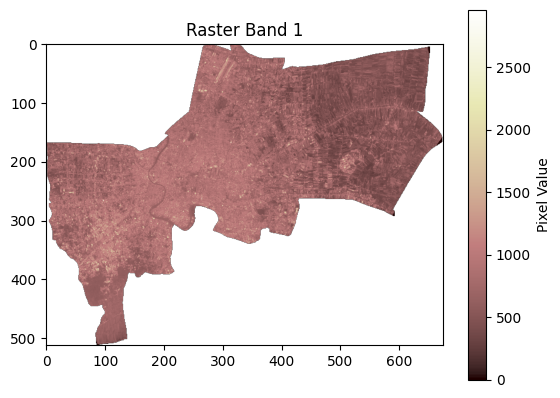

In [ ]:
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ raster
raster_path = "/content/drive/MyDrive/Colab Notebooks/PlanetScope_BKK_2023 (1).tif"

# เปิดไฟล์ raster ด้วย Rasterio
with rasterio.open(raster_path) as dataset:
  # อ่านข้อมูลจาก band ที่ต้องการ (เช่น band 1)
  band1 = dataset.read(1)

# แสดงผลด้วย Matplotlib
plt.imshow(band1, cmap='pink')  # เปลี่ยน cmap ตามต้องการ
plt.title("Raster Band 1")
plt.colorbar(label="Pixel Value")
plt.show()

แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [ ]:
!pip install rasterio

In [ ]:
import rasterio

# กำหนด path ของไฟล์ raster
raster_path = "/content/drive/MyDrive/Colab Notebooks/PlanetScope_BKK_2023 (1).tif"

# เปิดไฟล์ raster ด้วย Rasterio
with rasterio.open(raster_path) as dataset:
  # ดึงข้อมูลเมตา
  metadata = dataset.meta

  # แสดงผลข้อมูลเมตา
  print("ข้อมูลเมตาของภาพ Raster:")
  for key, value in metadata.items():
    print(f"{key}: {value}")

  # อธิบายค่าต่างๆ
  print("\nคำอธิบายค่าต่างๆ:")
  print(f"driver: {metadata['driver']} (รูปแบบไฟล์)")
  print(f"dtype: {metadata['dtype']} (ประเภทข้อมูล)")
  print(f"width: {metadata['width']} (ความกว้างของภาพเป็นพิกเซล)")
  print(f"height: {metadata['height']} (ความสูงของภาพเป็นพิกเซล)")
  print(f"count: {metadata['count']} (จำนวน band)")
  print(f"crs: {metadata['crs']} (ระบบอ้างอิงพิกัด)")
  print(f"transform: {metadata['transform']} (การแปลงพิกัด)")

ข้อมูลเมตาของภาพ Raster:
driver: GTiff
dtype: float32
nodata: None
width: 675
height: 513
count: 10
crs: EPSG:4326
transform: | 0.00, 0.00, 100.33|
| 0.00,-0.00, 13.95|
| 0.00, 0.00, 1.00|

คำอธิบายค่าต่างๆ:
driver: GTiff (รูปแบบไฟล์)
dtype: float32 (ประเภทข้อมูล)
width: 675 (ความกว้างของภาพเป็นพิกเซล)
height: 513 (ความสูงของภาพเป็นพิกเซล)
count: 10 (จำนวน band)
crs: EPSG:4326 (ระบบอ้างอิงพิกัด)
transform: | 0.00, 0.00, 100.33|
| 0.00,-0.00, 13.95|
| 0.00, 0.00, 1.00| (การแปลงพิกัด)


แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

In [ ]:
!pip install rasterio numpy matplotlib

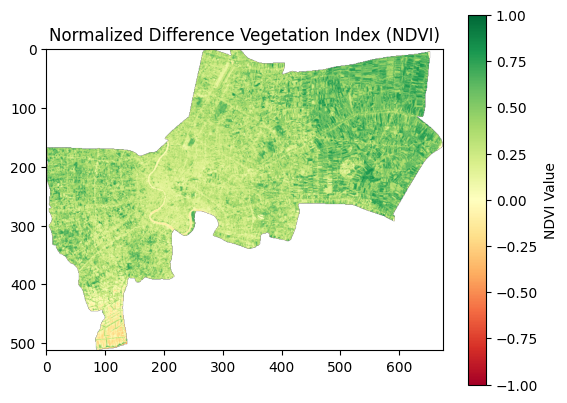

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ raster
raster_path = "/content/drive/MyDrive/Colab Notebooks/PlanetScope_BKK_2023 (1).tif"

# เปิดไฟล์ raster ด้วย Rasterio
with rasterio.open(raster_path) as dataset:
    # อ่านข้อมูลจาก band NIR (band 4) และ band Red (band 3)
    nir = dataset.read(4).astype(float)
    red = dataset.read(3).astype(float)

    # คำนวณ NDVI
    ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผลแผนที่ NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1) # ใช้ colormap RdYlGn สำหรับ NDVI
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()

แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [ ]:
!pip install rasterio geopandas shapely

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# กำหนด path ของไฟล์ raster และ shapefile
raster_path = "/content/drive/MyDrive/Colab Notebooks/PlanetScope_BKK_2023 (1).tif"
shapefile_path = "boundary.shp"  # หรือ path ที่ถูกต้องของ shapefile

# โหลดไฟล์ Shapefile
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])] # สมมติว่า shapefile มี polygon เดียว

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

ตัดข้อมูล Raster สำเร็จ!


6606614714 ธนัชชาา สันติเตชกุล